In [5]:
import torch

*   https://pytorch.org/blog/quantization-in-practice/
*   https://pytorch.org/docs/stable/quantization.html
*   https://pytorch.org/docs/stable/quantization-support.html

### Mapping function and Quantization Parameters

In [1]:
# r - float tensor, r' - int tensor
# S [scaling factor] = (beta - alpha) / (beta_q - alpha_q)
# Z [zero point] =  -(alpha / S - alpha_q)

def quantize(float_tensor, scale, z):
  # Q(r) = round(r/S + Z)
  return torch.round(float_tensor / scale + z)

def dequantize(int_tensor, scale, z):
  # r' = (Q(r) - Z) * S
  return (int_tensor - z) * scale

In [6]:
from torch.ao.quantization.observer import MinMaxObserver, MovingAverageMinMaxObserver, HistogramObserver

C, L = 3, 4
normal = torch.distributions.normal.Normal(0,1)
inputs = normal.sample((C, L))
print(inputs)

tensor([[ 1.5934,  0.2771, -0.4181, -0.4872],
        [ 0.3183,  0.0451,  0.9103,  0.3811],
        [-0.7482, -0.1983, -0.5426,  1.6623]])


In [7]:
observers = [MinMaxObserver(), MovingAverageMinMaxObserver(), HistogramObserver()]
for obs in observers:
  obs(inputs)
  print(obs.__class__.__name__, obs.calculate_qparams())

MinMaxObserver (tensor([0.0095]), tensor([79], dtype=torch.int32))
MovingAverageMinMaxObserver (tensor([0.0095]), tensor([79], dtype=torch.int32))
HistogramObserver (tensor([0.0094]), tensor([79], dtype=torch.int32))


In [8]:
scale, z = observers[0].calculate_qparams()
reconstruction_error = torch.abs(dequantize(quantize(inputs, scale, z), scale, z) - inputs)
reconstruction_error

tensor([[0.0041, 0.0030, 0.0022, 0.0044],
        [0.0031, 0.0022, 0.0028, 0.0029],
        [0.0014, 0.0003, 0.0038, 0.0014]])

### Affine and Symmetric Quantization Schemes

In [9]:
import numpy as np
import matplotlib.pyplot as plt


def get_symmetric_range(x):
  beta = torch.max(x.max(), x.min().abs())
  return -beta.item(), beta.item()

def get_affine_range(x):
  return x.min().item(), x.max().item()

def plot(plt, data, scheme):
  boundaries = get_affine_range(data) if scheme == 'affine' else get_symmetric_range(data)
  a, _, _ = plt.hist(data, density=True, bins=100)
  ymin, ymax = np.quantile(a[a>0], [0.25, 0.95])
  plt.vlines(x=boundaries, ls='--', colors='purple', ymin=ymin, ymax=ymax)

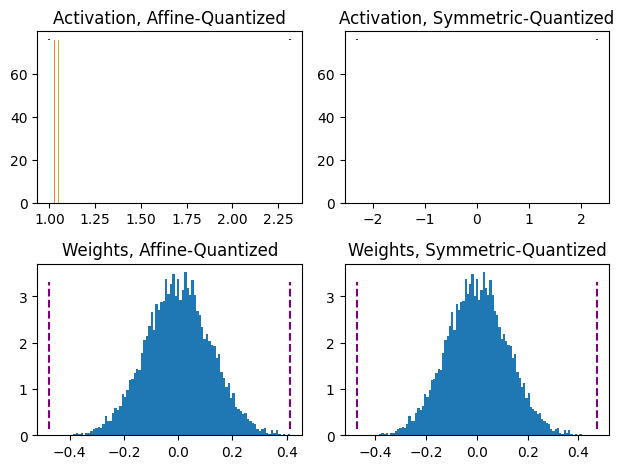

In [10]:
act =  torch.distributions.pareto.Pareto(1, 10).sample((1, 1024))
weights = torch.distributions.normal.Normal(0, 0.12).sample((3, 64, 7, 7)).flatten()

fig, axs = plt.subplots(2,2)
plot(axs[0, 0], act, 'affine')
axs[0, 0].set_title("Activation, Affine-Quantized")

plot(axs[0, 1], act, 'symmetric')
axs[0, 1].set_title("Activation, Symmetric-Quantized")

plot(axs[1, 0], weights, 'affine')
axs[1, 0].set_title("Weights, Affine-Quantized")

plot(axs[1, 1], weights, 'symmetric')
axs[1, 1].set_title("Weights, Symmetric-Quantized")

fig.tight_layout()
plt.show()

In [11]:
for qscheme in [torch.per_tensor_affine, torch.per_tensor_symmetric]:
  obs = MovingAverageMinMaxObserver(qscheme=qscheme)
  obs(inputs)
  print(f"Qscheme: {qscheme} | {obs.calculate_qparams()}")

Qscheme: torch.per_tensor_affine | (tensor([0.0095]), tensor([79], dtype=torch.int32))
Qscheme: torch.per_tensor_symmetric | (tensor([0.0130]), tensor([128]))


### Per-Tensor and Per-Channel Quantization Schemes

In [17]:
from torch.ao.quantization.observer import MovingAveragePerChannelMinMaxObserver

obs = MovingAveragePerChannelMinMaxObserver(ch_axis = 0)  # calculate qparams for all `C` channels separately
obs(inputs)
print(obs.calculate_qparams())

(tensor([0.0082, 0.0036, 0.0095]), tensor([60,  0, 79], dtype=torch.int32))


For weights quantization, symmetric-per-channel quantization provides better accuracies; per-tensor quantization performs poorly, possibly due to high variance in conv weights across channels from batchnorm folding.
[https://arxiv.org/abs/2004.09602]

https://github.com/pytorch/pytorch/blob/748d9d24940cd17938df963456c90fa1a13f3932/torch/ao/quantization/observer.py#L258

### Backend Engine

In [13]:
backend = 'fbgemm' #'fbgemm' if x86 else 'qnnpack' intel - oneDNN
qconfig = torch.ao.quantization.get_default_qconfig(backend)
torch.backends.quantized.engine = backend

GPUs - via TensorRT and cuDNN
https://pytorch.org/docs/stable/quantization.html#note-for-native-cpu-backends

### QConfig

In [14]:
my_qconfig = torch.ao.quantization.QConfig(
  activation=MovingAverageMinMaxObserver.with_args(qscheme=torch.per_tensor_affine),
  weight=MovingAveragePerChannelMinMaxObserver.with_args(qscheme=torch.qint8))

my_qconfig

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.MovingAverageMinMaxObserver'>, qscheme=torch.per_tensor_affine){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MovingAveragePerChannelMinMaxObserver'>, qscheme=torch.qint8){})

### Eager Mode v/s FX Graph Mode

*    Eager Mode Quantization is a beta feature. User needs to do fusion and specify where quantization and dequantization happens manually, also it only supports modules and not functionals.
*    FX Graph Mode Quantization is a new automated quantization framework in PyTorch, and currently it’s a prototype feature. It improves upon Eager Mode Quantization by adding support for functionals and automating the quantization process, although people might need to refactor the model to make the model compatible with FX Graph Mode Quantization (symbolically traceable with torch.fx)






FX Graph Mode automatically fuses eligible modules, inserts Quant/DeQuant stubs, calibrates the model and returns a quantized module - all in two method calls - but only for networks that are symbolic traceable. The examples below contain the calls using Eager Mode and FX Graph Mode for comparison.
https://pytorch.org/docs/stable/fx.html#torch.fx.symbolic_trace

In [15]:
def f(a, b):
    if b == True:
        return a
    else:
        return a * 2

In [20]:
f = torch.fx.symbolic_trace(f, concrete_args={'b': False})
assert f(3, True) == 6

AssertionError: b has been specialized to have value False but got another value

https://pytorch.org/docs/stable/fx.html

### Post-Training Dynamic/Weight-only Quantization

Here the model’s weights are pre-quantized; the activations are quantized on-the-fly (“dynamic”) during inference. The simplest of all approaches, it has a one line API call in torch.quantization.quantize_dynamic. Currently only Linear and Recurrent (LSTM, GRU, RNN) layers are supported for dynamic quantization



*   Can result in higher accuracies since the clipping range is exactly calibrated for each input
*   Calibrating and quantizing the activations at each layer during runtime can add to the compute overhead



In [21]:
from torch import nn

# toy model
m = nn.Sequential(
  nn.Conv2d(2, 64, (8,)),
  nn.ReLU(),
  nn.Linear(16, 10),
  nn.LSTM(10, 10))

m.eval()

Sequential(
  (0): Conv2d(2, 64, kernel_size=(8,), stride=(1, 1))
  (1): ReLU()
  (2): Linear(in_features=16, out_features=10, bias=True)
  (3): LSTM(10, 10)
)

In [22]:
## EAGER MODE
from torch.ao.quantization import quantize_dynamic

model_quantized = quantize_dynamic(
    model=m, qconfig_spec={nn.LSTM, nn.Linear}, dtype=torch.qint8, inplace=False
)

/tmp/ipykernel_517922/2181302342.py:4: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = quantize_dynamic(


In [23]:
## FX MODE
from torch.ao.quantization import quantize_fx

example_inputs = (torch.randn(1, 3, 224, 224),)
qconfig_dict = {"": torch.ao.quantization.default_dynamic_qconfig}  # An empty key denotes the default applied to all modules
model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)
model_quantized = quantize_fx.convert_fx(model_prepared)

/tmp/ipykernel_517922/15622409.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)
/data/homes/makarov_vd/.conda/envs/fw/lib/python3.14/site-packages/torch/ao/quantization/quantize_fx.py:146: FutureWarning: Passing a QConfig dictionary to prepare is deprecated and will not be supported in a future v

In [24]:
torch.ao.quantization.default_dynamic_qconfig

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.PlaceholderObserver'>, dtype=torch.quint8, quant_min=0, quant_max=255, is_dynamic=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_tensor_symmetric){})

### Post-Training Static Quantization (PTQ)

PTQ also pre-quantizes model weights but instead of calibrating activations on-the-fly, the clipping range is pre-calibrated and fixed (“static”) using validation data. Activations stay in quantized precision between operations during inference. About 100 mini-batches of representative data are sufficient to calibrate the observers

*   Static quantization has faster inference than dynamic quantization because it eliminates the float<->int conversion costs between layers
*   Static quantized models may need regular re-calibration to stay robust against distribution-drift



In [25]:
# Static quantization of a model consists of the following steps:

#     Fuse modules
#     Insert Quant/DeQuant Stubs
#     Prepare the fused module (insert observers before and after layers)
#     Calibrate the prepared module (pass it representative data)
#     Convert the calibrated module (replace with quantized version)

import torch
from torch import nn
import copy

backend = "fbgemm"  # running on a x86 CPU. Use "qnnpack" if running on ARM.

model = nn.Sequential(
     nn.Conv2d(2, 64, 3),
     nn.ReLU(),
     nn.Conv2d(64, 128, 3),
     nn.ReLU()
)

In [26]:
## EAGER MODE
m = copy.deepcopy(model)
m.eval()

"""Fuse
- Inplace fusion replaces the first module in the sequence with the fused module, and the rest with identity modules
"""
torch.ao.quantization.fuse_modules(m, ['0','1'], inplace=True) # fuse first Conv-ReLU pair
torch.ao.quantization.fuse_modules(m, ['2','3'], inplace=True) # fuse second Conv-ReLU pair

"""Insert stubs"""
m = nn.Sequential(torch.ao.quantization.QuantStub(),
                  *m,
                  torch.ao.quantization.DeQuantStub())

"""Prepare"""
m.qconfig = torch.ao.quantization.get_default_qconfig(backend)
torch.ao.quantization.prepare(m, inplace=True)

"""Calibrate
- This example uses random data for convenience. Use representative (validation) data instead.
"""
with torch.inference_mode():
  for _ in range(10):
    x = torch.rand(1, 2, 28, 28)
    m(x)

"""Convert"""
torch.ao.quantization.convert(m, inplace=True)

"""Check"""
print(m[1].weight().element_size()) # 1 byte instead of 4 bytes for FP32

1


/tmp/ipykernel_517922/213743822.py:18: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.ao.quantization.prepare(m, inplace=True)
/data/homes/makarov_vd/.conda/envs/fw/lib/python3.14/site-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecate

In [27]:
m[1].weight()

tensor([[[[-0.1391, -0.0183,  0.2325],
          [-0.1062,  0.1062,  0.0458],
          [ 0.1428,  0.2032,  0.1812]],

         [[-0.0293,  0.1812,  0.1519],
          [-0.1007,  0.0586, -0.1025],
          [ 0.1043,  0.1904,  0.1227]]],


        [[[ 0.1750,  0.1075, -0.0419],
          [-0.0638,  0.0310,  0.1148],
          [ 0.0510, -0.0838,  0.0711]],

         [[-0.0255, -0.0073,  0.2133],
          [-0.1932, -0.2315,  0.0583],
          [ 0.2278, -0.0802,  0.1877]]],


        [[[-0.0655,  0.1683, -0.2268],
          [-0.1010,  0.1382, -0.0124],
          [-0.0903,  0.2179, -0.1913]],

         [[ 0.0443, -0.0691,  0.0602],
          [-0.1842,  0.0018, -0.1860],
          [-0.0124,  0.1736, -0.1399]]],


        ...,


        [[[ 0.0966,  0.0401, -0.0620],
          [ 0.1002, -0.2114,  0.1804],
          [ 0.1166,  0.2315,  0.1750]],

         [[-0.0747,  0.0510,  0.1075],
          [ 0.1841, -0.0164, -0.1914],
          [ 0.2315,  0.0565, -0.0711]]],


        [[[-0.0141, -0.21

In [28]:
## FX GRAPH
from torch.ao.quantization import quantize_fx

m = copy.deepcopy(model)
m.eval()
qconfig_dict = {"": torch.ao.quantization.get_default_qconfig(backend)}

# Prepare
example_inputs = (torch.randn(1, 3, 224, 224),)
model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)

# Calibrate - Use representative (validation) data.
with torch.inference_mode():
  for _ in range(10):
    x = torch.rand(1, 2, 28, 28)
    model_prepared(x)

# quantize
model_quantized = quantize_fx.convert_fx(model_prepared)

/tmp/ipykernel_517922/750729956.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)
/tmp/ipykernel_517922/750729956.py:19: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torc

### SENSITIVITY ANALYSIS

In [29]:
# ONE-AT-A-TIME SENSITIVITY ANALYSIS

for quantized_layer, _ in model.named_modules():
  print("Only quantizing layer: ", quantized_layer)

  # The module_name key allows module-specific qconfigs.
  qconfig_dict = {"": None,
  "module_name":[(quantized_layer, torch.quantization.get_default_qconfig(backend))]}

  example_inputs = (torch.randn(1, 3, 224, 224),)
  model_prepared = quantize_fx.prepare_fx(model, qconfig_dict, example_inputs)
  # calibrate
  model_quantized = quantize_fx.convert_fx(model_prepared)
  # evaluate(model)

Only quantizing layer:  
Only quantizing layer:  0
Only quantizing layer:  1
Only quantizing layer:  2
Only quantizing layer:  3


/tmp/ipykernel_517922/1147990886.py:11: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = quantize_fx.prepare_fx(model, qconfig_dict, example_inputs)
/tmp/ipykernel_517922/1147990886.py:13: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize

 Numeric Suite - https://pytorch.org/tutorials/prototype/numeric_suite_tutorial.html

In [30]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
import os
import torch.ao.quantization
import torch.ao.ns._numeric_suite as ns
from torch.ao.quantization import (
    default_eval_fn,
    default_qconfig,
    quantize,
)

In [31]:
float_model = torchvision.models.quantization.resnet18(pretrained=True, quantize=False)
float_model.to('cpu')
float_model.eval()
float_model.fuse_model()
float_model.qconfig = torch.quantization.default_qconfig
img_data = (torch.rand(2, 3, 10, 10, dtype=torch.float), torch.randint(0, 1, (2,), dtype=torch.long))
qmodel = quantize(float_model, default_eval_fn, [[img_data]], inplace=False)

/data/homes/makarov_vd/.conda/envs/fw/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/homes/makarov_vd/.conda/envs/fw/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /data/homes/makarov_vd/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 6.20MB/s]
/tmp/ipykernel_517922/409614095.py:7: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  qmodel = quantize(float_model, default_eval_fn, [[img_data]], inplace=False)


In [32]:
def compute_error(x, y):
    Ps = torch.norm(x)
    Pn = torch.norm(x - y)
    return 20 * torch.log10(Ps/Pn)

wt_compare_dict = ns.compare_weights(float_model.state_dict(), qmodel.state_dict())
for key in wt_compare_dict:
    print(key, compute_error(wt_compare_dict[key]['float'], wt_compare_dict[key]['quantized'].dequantize()))

print("---")

act_compare_dict = ns.compare_model_outputs(float_model, qmodel, img_data[0])
for key in act_compare_dict:
    print(key, compute_error(act_compare_dict[key]['float'][0], act_compare_dict[key]['quantized'][0].dequantize()))


conv1.weight tensor(31.6638)
layer1.0.conv1.weight tensor(30.6450)
layer1.0.conv2.weight tensor(31.1528)
layer1.1.conv1.weight tensor(32.1438)
layer1.1.conv2.weight tensor(31.2477)
layer2.0.conv1.weight tensor(30.9890)
layer2.0.conv2.weight tensor(28.8233)
layer2.0.downsample.0.weight tensor(31.5558)
layer2.1.conv1.weight tensor(30.7668)
layer2.1.conv2.weight tensor(28.4516)
layer3.0.conv1.weight tensor(30.9247)
layer3.0.conv2.weight tensor(26.6841)
layer3.0.downsample.0.weight tensor(28.7825)
layer3.1.conv1.weight tensor(28.9707)
layer3.1.conv2.weight tensor(25.6784)
layer4.0.conv1.weight tensor(26.8495)
layer4.0.conv2.weight tensor(25.8394)
layer4.0.downsample.0.weight tensor(28.6355)
layer4.1.conv1.weight tensor(26.8758)
layer4.1.conv2.weight tensor(28.4319)
fc._packed_params._packed_params tensor(32.6505)
---
conv1.stats tensor(37.4213, grad_fn=<MulBackward0>)
layer1.0.conv1.stats tensor(29.7512, grad_fn=<MulBackward0>)
layer1.0.conv2.stats tensor(28.3753, grad_fn=<MulBackward0>)
l

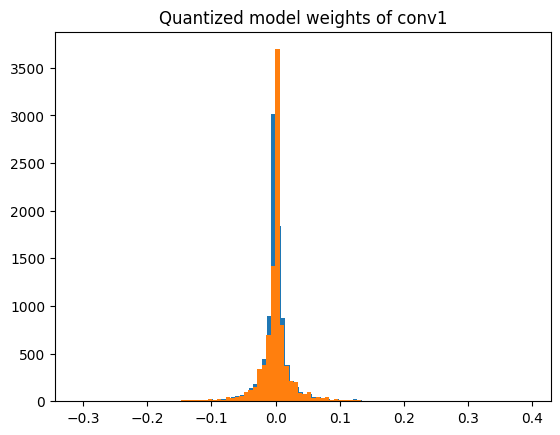

In [33]:
import matplotlib.pyplot as plt

f = wt_compare_dict['conv1.weight']['float'].flatten()
plt.hist(f, bins = 100)

q = wt_compare_dict['conv1.weight']['quantized'].flatten().dequantize()
plt.hist(q, bins = 100)
plt.title("Quantized model weights of conv1")
plt.show()

### RECOMMENDATIONS FOR YOUR WORKFLOW

![](https://drive.google.com/uc?export=view&id=1ij7GElwiKFNmJ221aKpkDRwMj5i-2DLh)



*   Large (10M+ parameters) models are more robust to quantization error
*   Quantizing a model from a FP32 checkpoint provides better accuracy than training an INT8 model from scratch
*   Dynamic Quantization is an easy first step, especially if your model has many Linear or Recurrent layers
*   Use symmetric-per-channel quantization with MinMax observers for quantizing weights. Use affine-per-tensor quantization with MovingAverageMinMax observers for quantizing activations
*   Use metrics like SQNR to identify which layers are most suscpetible to quantization error. Turn off quantization on these layers

Eager mode https://pytorch.org/docs/stable/quantization.html#eager-mode-quantization



*   https://pytorch.org/docs/stable/quantization.html#post-training-dynamic-quantization
*   https://pytorch.org/docs/stable/quantization.html#post-training-static-quantization


FX Graph https://pytorch.org/docs/stable/quantization.html#prototype-fx-graph-mode-quantization



*   https://pytorch.org/tutorials/prototype/fx_graph_mode_ptq_static.html
*   https://pytorch.org/tutorials/prototype/fx_graph_mode_ptq_dynamic.html





## New forkflow with torchao



In [37]:
import copy
import torch

class ToyLinearModel(torch.nn.Module):
    def __init__(self, m: int, n: int, k: int):
        super().__init__()
        self.linear1 = torch.nn.Linear(m, n, bias=False)
        self.linear2 = torch.nn.Linear(n, k, bias=False)

    def forward(self, x):
        x = self.linear1(x)
        x = self.linear2(x)
        return x

model = ToyLinearModel(1024, 1024, 1024).eval()

# Optional: compile model for faster inference and generation
model = torch.compile(model, mode="max-autotune", fullgraph=True)
model_f32 = copy.deepcopy(model)


In [50]:
from torchao.quantization import Int4DynamicActivationInt4WeightConfig, quantize_
quantize_(model, Int4DynamicActivationInt4WeightConfig())

ImportError: cannot import name 'Int4DynamicActivationInt4WeightConfig' from 'torchao.quantization' (/data/homes/makarov_vd/.conda/envs/fw/lib/python3.14/site-packages/torchao/quantization/__init__.py)

In [45]:
from torchao.utils import (
    benchmark_model,
    unwrap_tensor_subclass,
)

num_runs = 100
torch._dynamo.reset()
example_inputs = (torch.randn(1, 1024, dtype=torch.float32),)
f32_time = benchmark_model(model_f32, num_runs, example_inputs)
int4_time = benchmark_model(model, num_runs, example_inputs)

print("f32 mean time: %0.3f ms" % f32_time)
print("int4 mean time: %0.3f ms" % int4_time)
print("speedup: %0.1fx" % (f32_time / int4_time))

f32 mean time: 0.208 ms
int4 mean time: 0.000 ms
speedup: 938.5x


In [46]:
import os
torch.save(model, "/tmp/int4_model.pt")
torch.save(model_f32, "/tmp/f32_model.pt")
int4_model_size_mb = os.path.getsize("/tmp/int4_model.pt") / 1024 / 1024
f32_model_size_mb = os.path.getsize("/tmp/f32_model.pt") / 1024 / 1024

print("int4 model size: %.2f MB" % int4_model_size_mb)

print("f32 model size: %.2f MB" % f32_model_size_mb)


int4 model size: 8.00 MB
f32 model size: 8.00 MB


### Neural Network Compression Framework (NNCF)

In [47]:
!git clone https://github.com/openvinotoolkit/nncf

Cloning into 'nncf'...
remote: Enumerating objects: 99151, done.
remote: Counting objects: 100% (322/322), done.
remote: Compressing objects: 100% (202/202), done.
remote: Total 99151 (delta 213), reused 120 (delta 120), pack-reused 98829 (from 2)
Receiving objects: 100% (99151/99151), 70.60 MiB | 5.53 MiB/s, done.
Resolving deltas: 100% (66855/66855), done.


In [48]:
# %%capture
%cd nncf
!pip install .[torch]
%cd /content

/data/homes/makarov_vd/workspace/CCM/FW/MTAI2026-Deep-learning-frameworks-seminars/seminar_5/nncf
Processing ./.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 2.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 3.7 MB/s  0:00:02 eta 0:00:01
  Created wheel for nncf: filename=nncf-3.2.0.dev0+a94a1475b-py3-none-any.whl size=804358 sha256=cf7ef02baf8374246cfb924e487e03fab53a4f34c6b0ff8b595a3ea0e619fe71
  Stored in directory: /tmp/pip-ephem-wheel-cache-_aid0uw0/wheels/d6/c0/3d/01bc21076017b197a67ed49102c9f33256930b7ac4896407f8
Successfully built nncf
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [nncf]2m12/13 [nncf]t-learn]
[Errno 2] No such file or direc

In [49]:
import torch
import nncf.torch  # Important - must be imported before any other external package that depends on torch

https://github.com/openvinotoolkit/nncf/tree/develop
https://github.com/openvinotoolkit/nncf/blob/develop/docs/compression_algorithms/Quantization.md
https://github.com/openvinotoolkit/nncf/blob/develop/examples/torch/classification/configs/quantization/inception_v3_imagenet_int8.json

https://dev-discuss.pytorch.org/t/torch-ao-quantization-migration-plan/2810
https://docs.pytorch.org/ao/stable

**Домашнее задание**: реализовать Post Training Quantization для предобученной float32 torch2 модели на выбранном наборе данных. Квантизация обязательно должна проводиться с использованием калибровочной подвыборки. К результатам прилагаются мини результаты исследования влияния гиперпараметров квантизации (см. начало ноутбка). Необходимо показать разные варианты с учетом и без SENSITIVITY анализа. Разрешается использовать дополнительные фреймворки после обсуждения. Важно наличие таблиц скорость / качество / размер.

---

## PTQ с калибровочной подвыборкой, исследованием гиперпараметров и sensitivity analysis

In [62]:
import os
import time
import copy
import random
import tempfile
from dataclasses import dataclass

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T

from torch.utils.data import DataLoader, Subset

from torch.ao.quantization import (
    QConfig,
    QConfigMapping,
    MinMaxObserver,
    HistogramObserver,
    PerChannelMinMaxObserver,
)
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx

In [63]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def get_device() -> torch.device:
    # PTQ в этом ноутбуке ориентирован на CPU (backend x86).
    return torch.device("cpu")


def make_cifar10_loaders(
    root: str = "./data",
    batch_size: int = 64,
    calib_size: int = 256,
    val_size: int = 1024,
):
    # Препроцессинг в стиле ImageNet для предобученных весов ResNet18.
    transform = T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    train_ds = torchvision.datasets.CIFAR10(root=root, train=True, download=True, transform=transform)
    test_ds = torchvision.datasets.CIFAR10(root=root, train=False, download=True, transform=transform)

    calib_idx = list(range(min(calib_size, len(train_ds))))
    val_idx = list(range(min(val_size, len(test_ds))))

    calib_ds = Subset(train_ds, calib_idx)
    val_ds = Subset(test_ds, val_idx)

    calib_loader = DataLoader(calib_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    return calib_loader, val_loader


def evaluate_top1(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    max_batches: int | None = None,
    reference_model: nn.Module | None = None,
) -> float:
    """
    Если reference_model=None: обычный top1 по меткам датасета.
    Если reference_model задан: считаем agreement@1 с FP32-моделью.

    Для связки ImageNet-pretrained ResNet18 + CIFAR10
    прямой top1 по меткам CIFAR10 невалиден, поэтому
    в экспериментах ниже используем agreement@1.
    """
    model.eval().to(device)
    if reference_model is not None:
        reference_model.eval().to(device)

    correct = 0
    total = 0
    with torch.inference_mode():
        for i, (x, y) in enumerate(dataloader):
            if max_batches is not None and i >= max_batches:
                break

            x = x.to(device)
            out = model(x)
            pred = out.argmax(dim=1)

            if reference_model is None:
                target = y.to(device)
            else:
                ref_out = reference_model(x)
                target = ref_out.argmax(dim=1)

            correct += (pred == target).sum().item()
            total += target.numel()

    return 100.0 * correct / max(total, 1)


def calibrate_model(prepared_model: nn.Module, calib_loader: DataLoader, device: torch.device, max_batches: int | None = None):
    prepared_model.eval().to(device)
    with torch.inference_mode():
        for i, (x, _) in enumerate(calib_loader):
            if max_batches is not None and i >= max_batches:
                break
            prepared_model(x.to(device))


def benchmark_latency_ms(model: nn.Module, input_shape=(1, 3, 224, 224), warmup: int = 10, iters: int = 50) -> float:
    model.eval()
    x = torch.randn(*input_shape)
    with torch.inference_mode():
        for _ in range(warmup):
            _ = model(x)
        t0 = time.perf_counter()
        for _ in range(iters):
            _ = model(x)
        t1 = time.perf_counter()
    return (t1 - t0) * 1000.0 / iters


def model_size_mb(model: nn.Module) -> float:
    with tempfile.NamedTemporaryFile(suffix=".pt", delete=False) as f:
        tmp_path = f.name
    try:
        torch.save(model.state_dict(), tmp_path)
        return os.path.getsize(tmp_path) / (1024 ** 2)
    finally:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)


def make_float_resnet18() -> nn.Module:
    # Стандартная предобученная float32-модель.
    weights = torchvision.models.ResNet18_Weights.DEFAULT
    model = torchvision.models.resnet18(weights=weights)
    model.eval()
    return model


def build_qconfig_mapping(backend: str = "x86", act_observer: str = "hist") -> QConfigMapping:
    if act_observer == "hist":
        activation_obs = HistogramObserver.with_args(reduce_range=True)
    elif act_observer == "minmax":
        activation_obs = MinMaxObserver.with_args(reduce_range=True)
    else:
        raise ValueError(f"Неизвестный act_observer={act_observer}")

    # per-channel (qint8, почти symmetric) для весов
    # affine per-tensor для активаций
    weight_obs = PerChannelMinMaxObserver.with_args(dtype=torch.qint8, qscheme=torch.per_channel_symmetric)

    qconfig = QConfig(activation=activation_obs, weight=weight_obs)
    return QConfigMapping().set_global(qconfig)


@dataclass
class VariantResult:
    variant: str
    top1: float
    latency_ms: float
    size_mb: float
    top1_drop_vs_f32: float

In [55]:
set_seed(42)
device = get_device()
backend = "x86"

# Обязательная калибровочная подвыборка явно формируется из train-части.
calib_loader, val_loader = make_cifar10_loaders(
    batch_size=64,
    calib_size=256,
    val_size=1024,
)

100%|██████████| 170M/170M [20:37<00:00, 138kB/s]    
/data/homes/makarov_vd/.conda/envs/fw/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [64]:
# Базовая float32-модель
float_model = make_float_resnet18().to(device)

# Для базовой модели agreement@1 с самой собой принимаем за 100%.
f32_agreement = 100.0
f32_latency = benchmark_latency_ms(float_model)
f32_size = model_size_mb(float_model)

print(f"Базовая float32 | agreement@1={f32_agreement:.2f}% | latency={f32_latency:.2f} ms | size={f32_size:.2f} MB")

Базовая float32 | agreement@1=100.00% | latency=7.06 ms | size=44.67 MB


In [65]:
# PTQ без sensitivity (базовый вариант)
qmap_default = build_qconfig_mapping(backend=backend, act_observer="hist")
example_inputs = (torch.randn(1, 3, 224, 224),)

prepared_default = prepare_fx(copy.deepcopy(float_model), qmap_default, example_inputs)
calibrate_model(prepared_default, calib_loader, device)
ptq_default = convert_fx(prepared_default).eval()

ptq_agreement = evaluate_top1(ptq_default, val_loader, device, reference_model=float_model)
ptq_latency = benchmark_latency_ms(ptq_default)
ptq_size = model_size_mb(ptq_default)

print(f"PTQ без sensitivity | agreement@1={ptq_agreement:.2f}% | latency={ptq_latency:.2f} ms | size={ptq_size:.2f} MB")

/tmp/ipykernel_517922/1661320936.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_default = prepare_fx(copy.deepcopy(float_model), qmap_default, example_inputs)
/data/homes/makarov_vd/.conda/envs/fw/lib/python3.14/site-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.          

PTQ без sensitivity | agreement@1=68.95% | latency=2.21 ms | size=11.29 MB


In [66]:
# Меняем observer для активаций и размер калибровочной подвыборки.

hyperparam_runs = []

for act_obs in ["hist", "minmax"]:
    for calib_size in [64, 256, 512]:
        calib_loader_hp, _ = make_cifar10_loaders(batch_size=64, calib_size=calib_size, val_size=1024)

        qmap = build_qconfig_mapping(backend=backend, act_observer=act_obs)
        prepared = prepare_fx(copy.deepcopy(float_model), qmap, example_inputs)
        calibrate_model(prepared, calib_loader_hp, device)
        qmodel = convert_fx(prepared).eval()

        agreement = evaluate_top1(qmodel, val_loader, device, reference_model=float_model)
        lat = benchmark_latency_ms(qmodel)
        size = model_size_mb(qmodel)

        hyperparam_runs.append(
            VariantResult(
                variant=f"PTQ-{act_obs}-calib{calib_size}",
                top1=agreement,
                latency_ms=lat,
                size_mb=size,
                top1_drop_vs_f32=f32_agreement - agreement,
            )
        )

hyper_df = pd.DataFrame([r.__dict__ for r in hyperparam_runs]).sort_values("top1", ascending=False)
hyper_df = hyper_df.rename(columns={"top1": "agreement_at1", "top1_drop_vs_f32": "agreement_drop_vs_f32"})
hyper_df

/data/homes/makarov_vd/.conda/envs/fw/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
/tmp/ipykernel_517922/3154057834.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/

,variant,agreement_at1,latency_ms,size_mb,agreement_drop_vs_f32
2,PTQ-hist-calib512,70.898438,2.441621,11.290458,29.101562
1,PTQ-hist-calib256,68.945312,2.187703,11.290458,31.054688
0,PTQ-hist-calib64,65.332031,2.225567,11.290458,34.667969
4,PTQ-minmax-calib256,59.472656,2.552365,11.290458,40.527344
3,PTQ-minmax-calib64,58.496094,2.463166,11.290458,41.503906
5,PTQ-minmax-calib512,55.859375,2.201286,11.290458,44.140625


In [67]:
# Анализ чувствительности: one-at-a-time, слой в FP32 
# Метод:
# 1) Берем обычный PTQ как базу
# 2) Для каждого квантуемого слоя отключаем квантизацию только для него
# 3) Считаем прирост качества относительно полного PTQ

quantizable_layers = [
    name
    for name, module in float_model.named_modules()
    if isinstance(module, (nn.Conv2d, nn.Linear))
]

print(f"Найдено квантуемых слоев: {len(quantizable_layers)}")

sensitivity_rows = []

# Чтобы выполнение оставалось разумным по времени, анализируем только первые N слоев
N_SENS_LAYERS = 16
layers_to_test = quantizable_layers[:N_SENS_LAYERS]

for layer_name in layers_to_test:
    qmap_layer = build_qconfig_mapping(backend=backend, act_observer="hist").set_module_name(layer_name, None)

    prepared_layer = prepare_fx(copy.deepcopy(float_model), qmap_layer, example_inputs)
    calibrate_model(prepared_layer, calib_loader, device)
    qmodel_layer = convert_fx(prepared_layer).eval()

    layer_agreement = evaluate_top1(qmodel_layer, val_loader, device, reference_model=float_model)
    gain_vs_full_ptq = layer_agreement - ptq_agreement

    sensitivity_rows.append(
        {
            "layer": layer_name,
            "agreement_with_layer_fp32": layer_agreement,
            "gain_vs_full_ptq": gain_vs_full_ptq,
        }
    )

sens_df = pd.DataFrame(sensitivity_rows).sort_values("gain_vs_full_ptq", ascending=False)
sens_df.head(10)

Найдено квантуемых слоев: 21


/tmp/ipykernel_517922/426615770.py:24: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_layer = prepare_fx(copy.deepcopy(float_model), qmap_layer, example_inputs)
/data/homes/makarov_vd/.conda/envs/fw/lib/python3.14/site-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.              

/tmp/ipykernel_517922/426615770.py:26: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  qmodel_layer = convert_fx(prepared_layer).eval()
/tmp/ipykernel_517922/426615770.py:24: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quanti

,layer,agreement_with_layer_fp32,gain_vs_full_ptq
0,conv1,74.902344,5.957031
1,layer1.0.conv1,69.921875,0.976562
5,layer2.0.conv1,69.824219,0.878906
13,layer3.1.conv1,69.335938,0.390625
7,layer2.0.downsample.0,69.140625,0.195312
4,layer1.1.conv2,69.140625,0.195312
8,layer2.1.conv1,69.140625,0.195312
3,layer1.1.conv1,69.140625,0.195312
11,layer3.0.conv2,68.945312,0.000000
12,layer3.0.downsample.0,68.847656,-0.097656


In [68]:
# PTQ с учетом sensitivity-исключений 
# Оставляем top-K самых чувствительных слоев в FP32 (то есть не квантуем их)

TOP_K = 4
sensitive_layers = sens_df.head(TOP_K)["layer"].tolist()
print("Выбранные чувствительные слои, которые остаются в FP32:")
for ln in sensitive_layers:
    print(" -", ln)

qmap_sens = build_qconfig_mapping(backend=backend, act_observer="hist")
for ln in sensitive_layers:
    qmap_sens = qmap_sens.set_module_name(ln, None)

prepared_sens = prepare_fx(copy.deepcopy(float_model), qmap_sens, example_inputs)
calibrate_model(prepared_sens, calib_loader, device)
ptq_sens = convert_fx(prepared_sens).eval()

ptq_sens_agreement = evaluate_top1(ptq_sens, val_loader, device, reference_model=float_model)
ptq_sens_latency = benchmark_latency_ms(ptq_sens)
ptq_sens_size = model_size_mb(ptq_sens)

print(f"PTQ + sensitivity | agreement@1={ptq_sens_agreement:.2f}% | задержка={ptq_sens_latency:.2f} ms | размер={ptq_sens_size:.2f} MB")

Выбранные чувствительные слои, которые остаются в FP32:
 - conv1
 - layer1.0.conv1
 - layer2.0.conv1
 - layer3.1.conv1


/tmp/ipykernel_517922/3279582057.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_sens = prepare_fx(copy.deepcopy(float_model), qmap_sens, example_inputs)
/data/homes/makarov_vd/.conda/envs/fw/lib/python3.14/site-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.               

PTQ + sensitivity | agreement@1=76.86% | задержка=3.85 ms | размер=13.31 MB


In [69]:
# Финальные таблицы сравнения

final_runs = [
    VariantResult(
        variant="FP32 база",
        top1=f32_agreement,
        latency_ms=f32_latency,
        size_mb=f32_size,
        top1_drop_vs_f32=0.0,
    ),
    VariantResult(
        variant="PTQ без sensitivity (hist, calib=256)",
        top1=ptq_agreement,
        latency_ms=ptq_latency,
        size_mb=ptq_size,
        top1_drop_vs_f32=f32_agreement - ptq_agreement,
    ),
    VariantResult(
        variant=f"PTQ + sensitivity (top{TOP_K} слоев в FP32)",
        top1=ptq_sens_agreement,
        latency_ms=ptq_sens_latency,
        size_mb=ptq_sens_size,
        top1_drop_vs_f32=f32_agreement - ptq_sens_agreement,
    ),
]

final_df = pd.DataFrame([r.__dict__ for r in final_runs])
final_df["speedup_vs_f32"] = final_df.loc[0, "latency_ms"] / final_df["latency_ms"]
final_df["compression_vs_f32"] = final_df.loc[0, "size_mb"] / final_df["size_mb"]

print("Основная таблица сравнения")
final_df = final_df.rename(columns={"top1": "agreement_at1", "top1_drop_vs_f32": "agreement_drop_vs_f32"})
final_df.sort_values("agreement_at1", ascending=False)

Основная таблица сравнения


,variant,agreement_at1,latency_ms,size_mb,agreement_drop_vs_f32,speedup_vs_f32,compression_vs_f32
0,FP32 база,100.000000,7.057774,44.666331,0.000000,1.000000,1.000000
2,PTQ + sensitivity (top4 слоев в FP32),76.855469,3.845383,13.311130,23.144531,1.835389,3.355563
1,"PTQ без sensitivity (hist, calib=256)",68.945312,2.206093,11.290458,31.054688,3.199218,3.956113
